In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from gsm_benchmarker.results_analyser import MultiModelResultsAnalyser
from gsm_benchmarker.answer_extractor import AnswerExtractor

plt.style.use('seaborn-v0_8-muted')
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
pp = Path("../../../../data/gsm-symbolic/outputs").resolve()
p_standard = pp / "mini_20x50x4__14_11/final"
p_sep = pp / 'separated_targets_20x50x4__26_11/final'
p_code = pp / 'mini_code_output_20x50__05_12/final'

In [3]:
res_standard = MultiModelResultsAnalyser(p_standard/'main_test', load_full_data=True)
res_sep = MultiModelResultsAnalyser(p_sep/'main_test', load_full_data=True)
res_code = MultiModelResultsAnalyser(p_code/'main_test', load_full_data=True)

Model: 100%|██████████| 20/20 [00:00<00:00, 58.94it/s]
/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/multi_model.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(full_data_dict.values(), keys=full_data_dict.keys(), names=['model', 'old_index'])
Model: 100%|██████████| 20/20 [00:00<00:00, 44.34it/s]


In [4]:
def print_qq(qq):
    print(f"MODEL: {qq['model']}")
    print(f"TEMPLATE ID: {qq['id']}")
    print("\nQUESTION")
    print(qq["question"])
    print(f"\nEXPECTED RESULT: {qq['numerical_result']}")
    print("\nANSWER")
    print(10*'-')
    t = AnswerExtractor.trim_response(qq["full_response"])
    print(t)
    if len(t) != len(qq['full_response']):
        print("...")
    print(10*'-')

    ret, e = AnswerExtractor.extract_answer_code(qq['full_response'])
    if ret is None:
        print("\nISSUE")
        print(e.name)

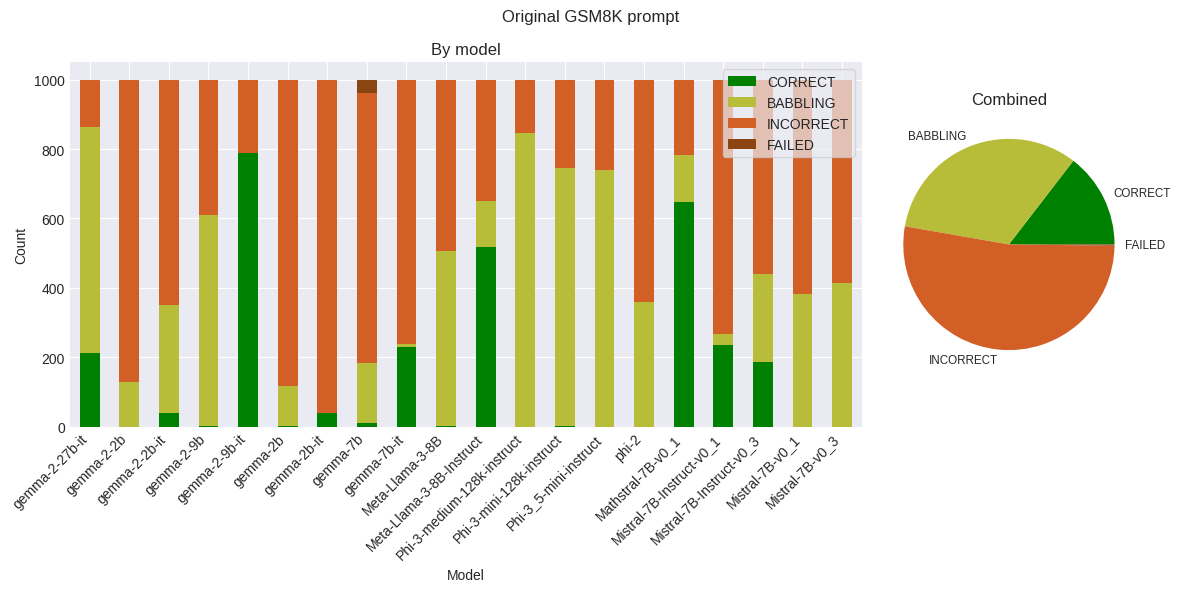

In [5]:
_ = res_standard.plot_result_class_by_model("Original GSM8K prompt")

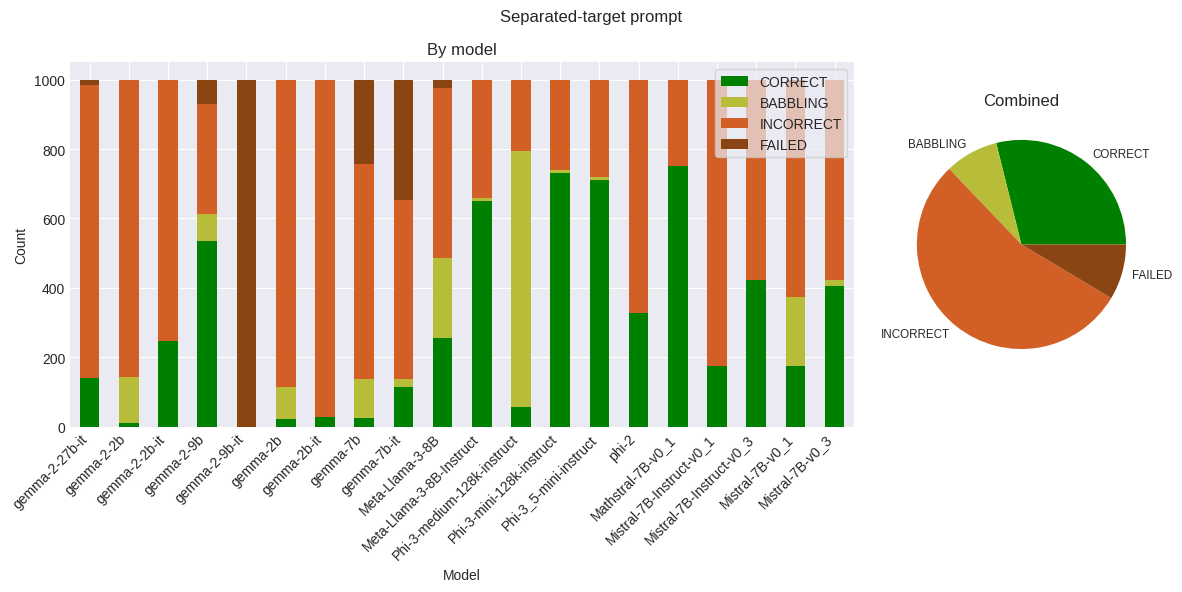

In [6]:
_ = res_sep.plot_result_class_by_model(title='Separated-target prompt')

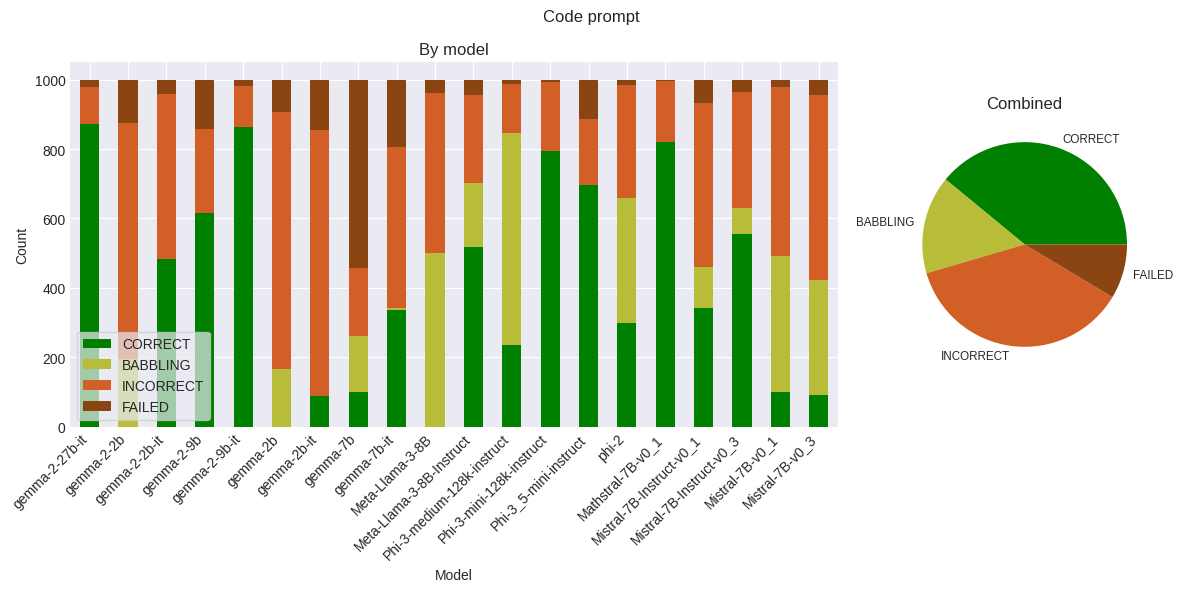

In [7]:
_ = res_code.plot_result_class_by_model(title='Code prompt')

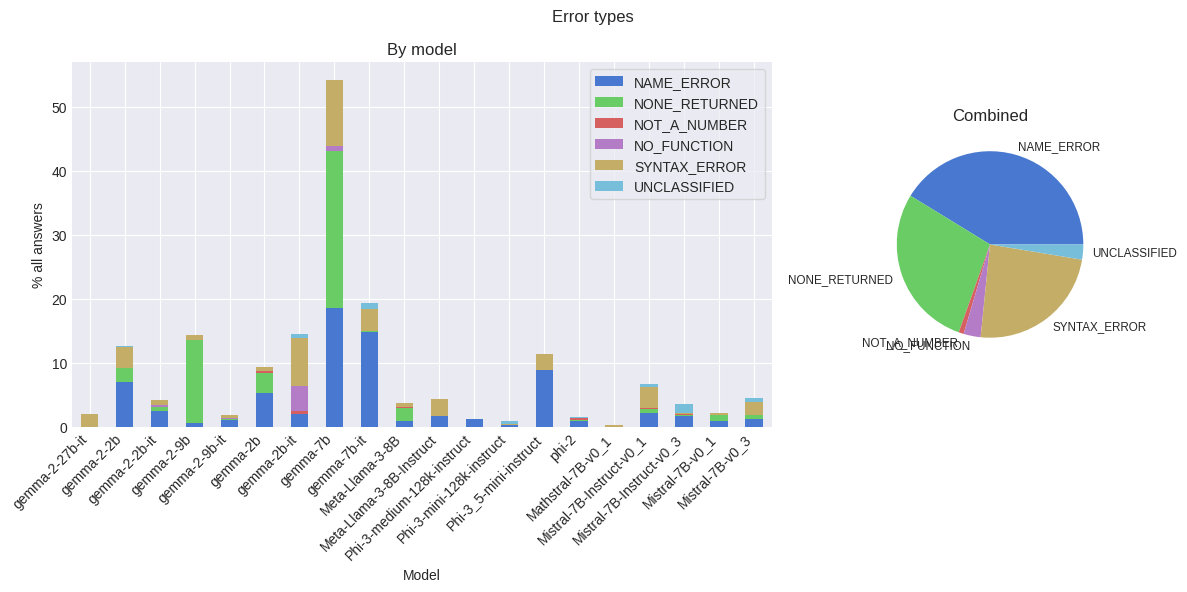

In [8]:
_ = res_code.plot_error_types_by_model(percentage=True)


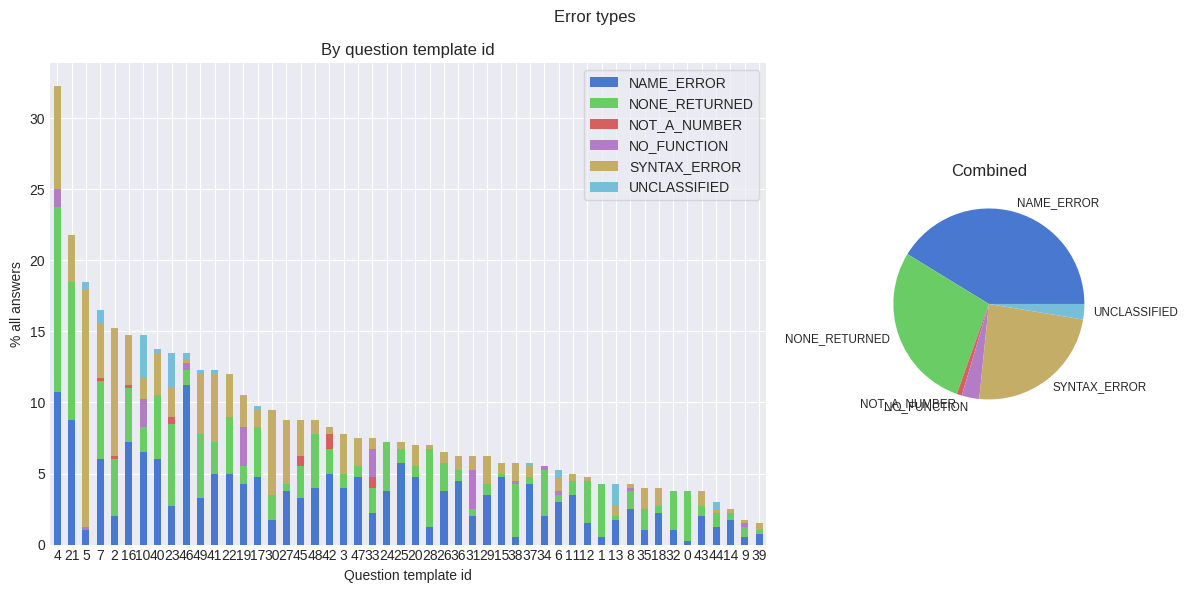

In [9]:
_ = res_code.plot_error_types_by_question_id(percentage=True)

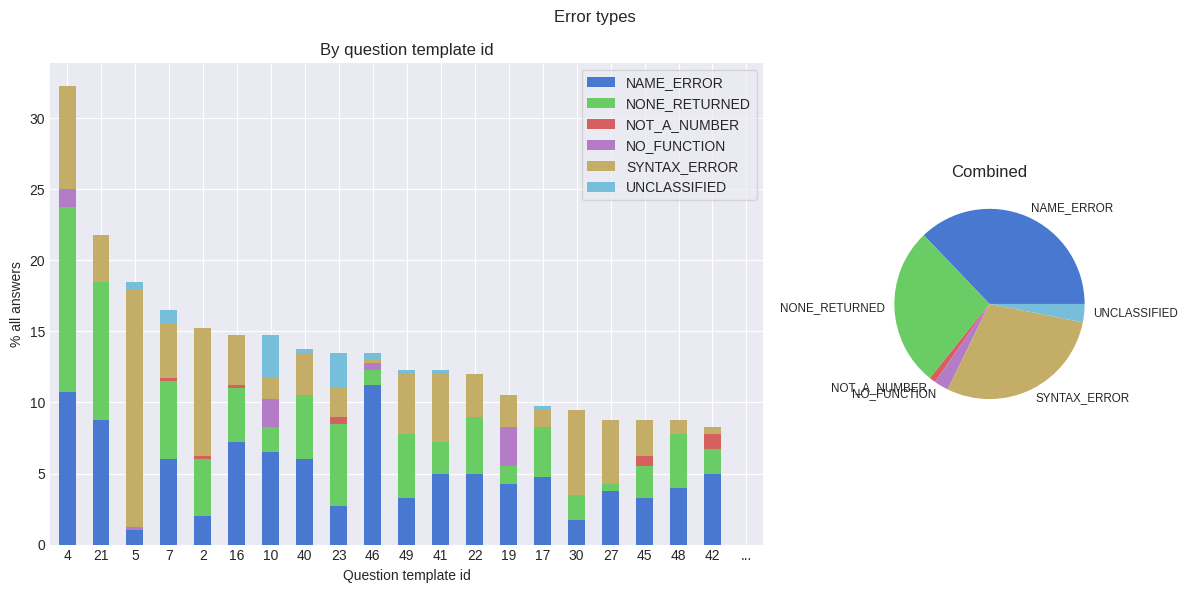

In [10]:
_ = res_code.plot_error_types_by_question_id(max_questions=20, percentage=True)